Projekt System Rekomendacji

MovieLens Latest Dataset small

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

movie_ratings = pd.merge(ratings, movies, on='movieId')

In [4]:
print(f"Załadowano {len(movie_ratings)} ocen.")
print(movie_ratings.head())

Załadowano 100836 ocen.
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


Które filmy są najczęściej oceniane

      movieId  rating_count                             title
314       356           329               Forrest Gump (1994)
277       318           317  Shawshank Redemption, The (1994)
257       296           307               Pulp Fiction (1994)
510       593           279  Silence of the Lambs, The (1991)
1938     2571           278                Matrix, The (1999)


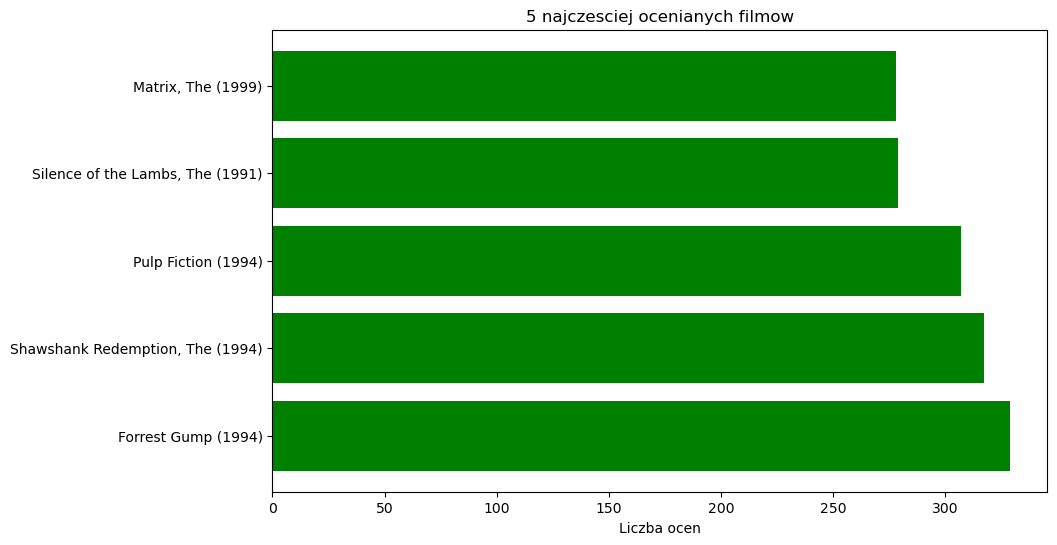

In [23]:
ratings_counts = movie_ratings.groupby('movieId').size()

top_movies = pd.DataFrame({
    'movieId':ratings_counts.index,
    'rating_count':ratings_counts.values
}).merge(movies[['movieId', 'title']], on='movieId')

top_movies = top_movies.sort_values('rating_count', ascending=False)

#print(top_movies.head(5))
top = top_movies.head(5)

plt.figure(figsize=(10,6))
bars = plt.barh(top['title'], top['rating_count'], color='green')
plt.xlabel('Liczba ocen')
plt.title('5 najczesciej ocenianych filmow')
plt.show()

In [32]:
# plt.figure(figsize=(10,4))
# ratings_counts['num_of_ratings'].hist(bins=70)
# plt.title('Rozkład liczby ocen (Większość filmów ma mało ocen)')
# plt.xlabel('Liczba ocen')
# plt.ylabel('Liczba filmów')
# plt.show()

Stworz macierz, wiersze userId, kolumny moviesId, wartosci to rating

In [45]:
user_rating_matrix = movie_ratings.pivot_table(
    index='userId',
    columns='title',#columns='movieId',
    values='rating'#, fill_value=0
)

print(user_rating_matrix.head())

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1              NaN                                      NaN   
2              NaN                                      NaN   
3              NaN                                      NaN   
4              NaN                                      NaN   
5              NaN                                      NaN   

title   'Round Midnight (1986)  'Salem's Lot (2004)  \
userId                                                
1                          NaN                  NaN   
2                          NaN                  NaN   
3                          NaN                  NaN   
4                          NaN                  NaN   
5                          NaN                  NaN   

title   'Til There Was You (1997)  'Tis the Season for Love (2015)  \
userId                                                               
1                             Na

pokazywanie rekomendacji danego filmu (zwraca filmy skorelowane z danymi)

In [51]:
def getRecomendation(movie_title, min_ratings=50):
    """ Funkcja zwraca filmy skorelowane z podanym tytułem. Args: movie_title (str): Tytuł filmu, np. 'Star Wars (1977)' min_ratings (int): Minimalna liczba ocen, jaką musi mieć film, by był brany pod uwagę (odrzucamy niszowe) """
    try:user_ratings = user_rating_matrix[movie_title]
    except KeyError:
        return "Film nie znaleziony w bazie."
    similar_movies = user_rating_matrix.corrwith(user_ratings)
    corr_df = pd.DataFrame(similar_movies, columns=['Correlation'])
    corr_df.dropna(inplace=True)
    corr_df = corr_df.join(ratings_counts['num_of_ratings'])
    recommendations = corr_df[corr_df['num_of_ratings'] > min_ratings].sort_values('Correlation', ascending=False)
    return recommendations.head(10)

In [52]:
print(getRecomendation("Jumanji (1995)"))

C:\Users\Mirek-Portable\miniconda3\envs\DataScience\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Mirek-Portable\miniconda3\envs\DataScience\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Mirek-Portable\miniconda3\envs\DataScience\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\Mirek-Portable\miniconda3\envs\DataScience\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Mirek-Portable\miniconda3\envs\DataScience\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyError: 'num_of_ratings'